# **Step 1 — Import Library & Load Data**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Library berhasil diimport!")

Library berhasil diimport!


In [ ]:
# 1. Menghubungkan ke Google Drive
print("Sedang meminta akses ke Google Drive...")
drive.mount('/content/drive')

# 2. Mendefinisikan Lokasi File
# Pastikan path ini benar (Klik ikon folder di kiri -> drive -> MyDrive -> cari file .csv -> klik kanan 'Copy Path')
file_path = '/content/drive/MyDrive/Dunia Data ku/Project/train.csv'

# 3. Membaca Dataset
print("Sedang membaca jutaan baris data... Harap bersabar.")
df = pd.read_csv(file_path)
print("Data berhasil dimuat sempurna!\n")
print("Jumlah baris dan kolom:", df.shape)
print("\n5 baris pertama data:")
df.head()

Sedang meminta akses ke Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Sedang membaca jutaan baris data... Harap bersabar.
Data berhasil dimuat sempurna!

Jumlah baris dan kolom: (233154, 41)

5 baris pertama data:


,UniqueID,disbursed_amount,asset_cost,ltv,branch_id,supplier_id,manufacturer_id,Current_pincode_ID,Date.of.Birth,Employment.Type,...,SEC.SANCTIONED.AMOUNT,SEC.DISBURSED.AMOUNT,PRIMARY.INSTAL.AMT,SEC.INSTAL.AMT,NEW.ACCTS.IN.LAST.SIX.MONTHS,DELINQUENT.ACCTS.IN.LAST.SIX.MONTHS,AVERAGE.ACCT.AGE,CREDIT.HISTORY.LENGTH,NO.OF_INQUIRIES,loan_default
0,420825,50578,58400,89.55,67,22807,45,1441,01-01-84,Salaried,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
1,537409,47145,65550,73.23,67,22807,45,1502,31-07-85,Self employed,...,0,0,1991,0,0,1,1yrs 11mon,1yrs 11mon,0,1
2,417566,53278,61360,89.63,67,22807,45,1497,24-08-85,Self employed,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
3,624493,57513,66113,88.48,67,22807,45,1501,30-12-93,Self employed,...,0,0,31,0,0,0,0yrs 8mon,1yrs 3mon,1,1
4,539055,52378,60300,88.39,67,22807,45,1495,09-12-77,Self employed,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,1,1


# **Step 2 — Kenali Dataset Lebih Dalam**

In [ ]:
# Cek tipe data setiap kolom dan nilai kosong
print("=== INFO DATASET ===")
df.info()

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 233154 entries, 0 to 233153
Data columns (total 41 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   UniqueID                             233154 non-null  int64  
 1   disbursed_amount                     233154 non-null  int64  
 2   asset_cost                           233154 non-null  int64  
 3   ltv                                  233154 non-null  float64
 4   branch_id                            233154 non-null  int64  
 5   supplier_id                          233154 non-null  int64  
 6   manufacturer_id                      233154 non-null  int64  
 7   Current_pincode_ID                   233154 non-null  int64  
 8   Date.of.Birth                        233154 non-null  object 
 9   Employment.Type                      225493 non-null  object 
 10  DisbursalDate                        233154 non-null  objec

In [ ]:
# Cek berapa banyak nilai kosong di setiap kolom
print("=== NILAI KOSONG PER KOLOM ===")
missing = df.isnull().sum()
missing_persen = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Jumlah Kosong': missing,
    'Persentase (%)': missing_persen
})

# Tampilkan hanya yang ada nilai kosongnya
print(missing_df[missing_df['Jumlah Kosong'] > 0])

=== NILAI KOSONG PER KOLOM ===
                 Jumlah Kosong  Persentase (%)
Employment.Type           7661            3.29


# **Step 3 — Eksplorasi Sebelum Cleaning**

In [ ]:
# Cek isi Employment.Type
print("=== Isi Employment.Type ===")
print(df['Employment.Type'].value_counts(dropna=False))

print("\n=== Contoh isi AVERAGE.ACCT.AGE ===")
print(df['AVERAGE.ACCT.AGE'].value_counts().head(10))

print("\n=== Contoh isi CREDIT.HISTORY.LENGTH ===")
print(df['CREDIT.HISTORY.LENGTH'].value_counts().head(10))

=== Isi Employment.Type ===
Employment.Type
Self employed    127635
Salaried          97858
NaN                7661
Name: count, dtype: int64

=== Contoh isi AVERAGE.ACCT.AGE ===
AVERAGE.ACCT.AGE
0yrs 0mon     119373
0yrs 6mon       6028
0yrs 7mon       5366
0yrs 11mon      5237
0yrs 10mon      5143
1yrs 0mon       5031
0yrs 9mon       5018
0yrs 8mon       4892
1yrs 1mon       4465
0yrs 5mon       4354
Name: count, dtype: int64

=== Contoh isi CREDIT.HISTORY.LENGTH ===
CREDIT.HISTORY.LENGTH
0yrs 0mon     119127
0yrs 6mon       4761
2yrs 1mon       4745
0yrs 7mon       4017
2yrs 0mon       3833
1yrs 0mon       3389
1yrs 1mon       3024
0yrs 11mon      2627
0yrs 8mon       2459
0yrs 9mon       2403
Name: count, dtype: int64


#**Step 4 — Data Cleaning**

In [ ]:
# Isi nilai kosong dengan modus (nilai terbanyak)
modus = df['Employment.Type'].mode()[0]
df['Employment.Type'] = df['Employment.Type'].fillna(modus)

print("Nilai kosong setelah diisi:", df['Employment.Type'].isnull().sum())
print("Modus yang dipakai:", modus)

Nilai kosong setelah diisi: 0
Modus yang dipakai: Self employed


In [ ]:
# Fungsi untuk mengubah "Xyrs Ymon" menjadi total bulan
def ubah_ke_bulan(teks):
    try:
        bagian = teks.split()
        tahun = int(bagian[0].replace('yrs', ''))
        bulan = int(bagian[1].replace('mon', ''))
        return (tahun * 12) + bulan
    except:
        return 0

df['AVERAGE.ACCT.AGE.MONTHS'] = df['AVERAGE.ACCT.AGE'].apply(ubah_ke_bulan)
df['CREDIT.HISTORY.LENGTH.MONTHS'] = df['CREDIT.HISTORY.LENGTH'].apply(ubah_ke_bulan)

print("Contoh hasil konversi AVERAGE.ACCT.AGE:")
print(df[['AVERAGE.ACCT.AGE', 'AVERAGE.ACCT.AGE.MONTHS']].head(5))

Contoh hasil konversi AVERAGE.ACCT.AGE:
  AVERAGE.ACCT.AGE  AVERAGE.ACCT.AGE.MONTHS
0        0yrs 0mon                        0
1       1yrs 11mon                       23
2        0yrs 0mon                        0
3        0yrs 8mon                        8
4        0yrs 0mon                        0


In [ ]:
# Ubah kolom tanggal ke tipe datetime
df['Date.of.Birth'] = pd.to_datetime(df['Date.of.Birth'], format='%d-%m-%y', errors='coerce')
df['DisbursalDate'] = pd.to_datetime(df['DisbursalDate'], format='%d-%m-%y', errors='coerce')

# Hitung usia nasabah saat pencairan
df['Usia'] = (df['DisbursalDate'] - df['Date.of.Birth']).dt.days // 365

print("Contoh hasil:")
print(df[['Date.of.Birth', 'DisbursalDate', 'Usia']].head(5))

Contoh hasil:
  Date.of.Birth DisbursalDate  Usia
0    1984-01-01    2018-08-03    34
1    1985-07-31    2018-09-26    33
2    1985-08-24    2018-08-01    32
3    1993-12-30    2018-10-26    24
4    1977-12-09    2018-09-26    40


In [ ]:
print("=== CEK AKHIR SETELAH CLEANING ===")
print("Nilai kosong tersisa:", df.isnull().sum().sum())
print("Shape data:", df.shape)
print("\nKolom baru yang ditambahkan:")
print(df[['AVERAGE.ACCT.AGE.MONTHS', 'CREDIT.HISTORY.LENGTH.MONTHS', 'Usia']].describe())

=== CEK AKHIR SETELAH CLEANING ===
Nilai kosong tersisa: 0
Shape data: (233154, 44)

Kolom baru yang ditambahkan:
       AVERAGE.ACCT.AGE.MONTHS  CREDIT.HISTORY.LENGTH.MONTHS           Usia
count            233154.000000                 233154.000000  233154.000000
mean                  8.915764                     16.252404      25.429922
std                  15.106416                     28.581255      23.151273
min                   0.000000                      0.000000     -51.000000
25%                   0.000000                      0.000000      24.000000
50%                   0.000000                      0.000000      30.000000
75%                  13.000000                     24.000000      37.000000
max                 369.000000                    468.000000      49.000000


In [ ]:
# Cek nasabah dengan usia negatif atau tidak masuk akal
print("Nasabah dengan usia < 0:")
print(df[df['Usia'] < 0][['Date.of.Birth', 'DisbursalDate', 'Usia']].head(10))

print("\nNasabah dengan usia > 70:")
print(df[df['Usia'] > 70][['Date.of.Birth', 'DisbursalDate', 'Usia']].head(10))

print("\nDistribusi usia:")
print(df['Usia'].describe())

Nasabah dengan usia < 0:
    Date.of.Birth DisbursalDate  Usia
9      2068-06-01    2018-09-16   -50
26     2068-08-02    2018-08-16   -50
32     2066-06-01    2018-09-12   -48
59     2064-06-01    2018-08-24   -46
68     2067-01-01    2018-09-19   -49
72     2067-01-01    2018-10-13   -49
97     2068-01-01    2018-10-23   -50
111    2067-01-01    2018-08-08   -49
128    2062-01-01    2018-09-18   -44
167    2065-05-01    2018-10-22   -47

Nasabah dengan usia > 70:
Empty DataFrame
Columns: [Date.of.Birth, DisbursalDate, Usia]
Index: []

Distribusi usia:
count    233154.000000
mean         25.429922
std          23.151273
min         -51.000000
25%          24.000000
50%          30.000000
75%          37.000000
max          49.000000
Name: Usia, dtype: float64


In [ ]:
# Hitung berapa banyak data dengan usia bermasalah
usia_negatif = df[df['Usia'] < 0].shape[0]
usia_wajar = df[(df['Usia'] >= 18) & (df['Usia'] <= 70)].shape[0]
usia_terlalu_muda = df[(df['Usia'] >= 0) & (df['Usia'] < 18)].shape[0]

print(f"Usia negatif (tahun salah baca): {usia_negatif} baris ({usia_negatif/len(df)*100:.2f}%)")
print(f"Usia terlalu muda < 18 tahun: {usia_terlalu_muda} baris ({usia_terlalu_muda/len(df)*100:.2f}%)")
print(f"Usia wajar 18-70 tahun: {usia_wajar} baris ({usia_wajar/len(df)*100:.2f}%)")

Usia negatif (tahun salah baca): 19866 baris (8.52%)
Usia terlalu muda < 18 tahun: 0 baris (0.00%)
Usia wajar 18-70 tahun: 213288 baris (91.48%)


In [ ]:
# Perbaiki tahun yang salah baca (2068 -> 1968, dll)
def perbaiki_tahun(tanggal):
    if pd.isnull(tanggal):
        return tanggal
    if tanggal.year > 2023:
        return tanggal.replace(year=tanggal.year - 100)
    return tanggal

df['Date.of.Birth'] = df['Date.of.Birth'].apply(perbaiki_tahun)

# Hitung ulang usia
df['Usia'] = (df['DisbursalDate'] - df['Date.of.Birth']).dt.days // 365

# Verifikasi hasil
print("=== SETELAH PERBAIKAN ===")
print(f"Usia negatif tersisa: {df[df['Usia'] < 0].shape[0]}")
print(f"Usia wajar 18-70 tahun: {df[(df['Usia'] >= 18) & (df['Usia'] <= 70)].shape[0]}")
print(f"\nDistribusi usia sekarang:")
print(df['Usia'].describe())

=== SETELAH PERBAIKAN ===
Usia negatif tersisa: 0
Usia wajar 18-70 tahun: 233154

Distribusi usia sekarang:
count    233154.000000
mean         33.954142
std           9.821186
min          18.000000
25%          26.000000
50%          32.000000
75%          41.000000
max          69.000000
Name: Usia, dtype: float64


# **Step 5 — Simpan Data Bersih**

In [ ]:
# Simpan data yang sudah bersih
clean_path = '/content/drive/MyDrive/Dunia Data ku/Project/Project PT dipo star finance/train_clean.csv'
df.to_csv(clean_path, index=False)
print("Data bersih berhasil disimpan!")
print(f"Shape final: {df.shape}")

Data bersih berhasil disimpan!
Shape final: (233154, 44)


# **Step 6: Exploratory Data Analysis (EDA)**

Pertanyaan bisnis yang akan kita jawab:

* Berapa persen nasabah yang gagal bayar?
* Jenis pekerjaan apa yang paling berisiko gagal bayar?
* Apakah LTV tinggi berbanding lurus dengan risiko gagal bayar?
* Usia berapa nasabah paling sering gagal bayar?
* Apakah skor kredit benar-benar prediktif?



## Pertanyaan 1: Berapa persen nasabah yang gagal bayar?

=== DISTRIBUSI LOAN DEFAULT ===
Tidak Gagal Bayar (0): 182,543 nasabah (78.3%)
Gagal Bayar (1):       50,611 nasabah (21.7%)


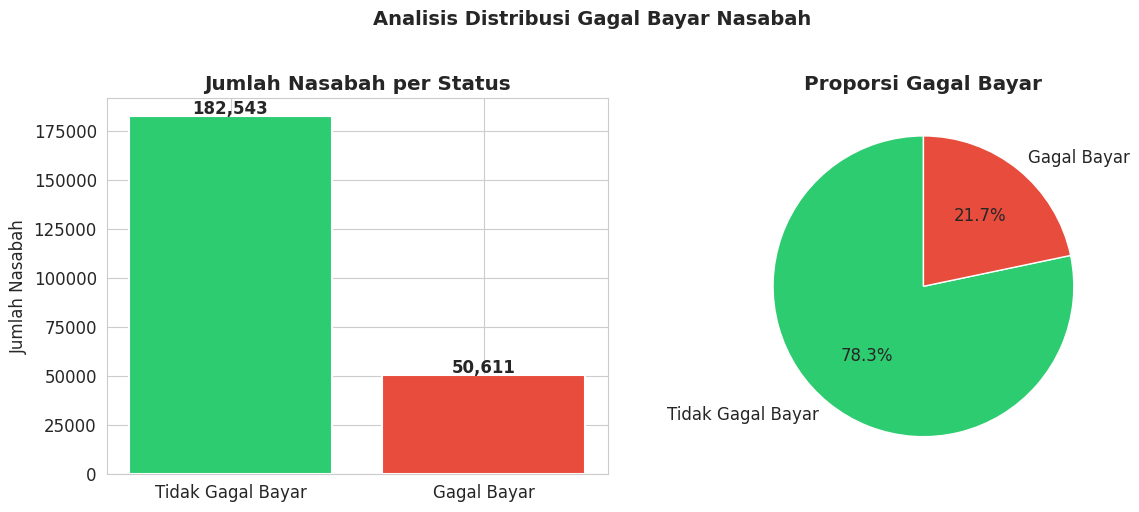

Chart 1 berhasil disimpan!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setting tampilan grafik
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

# Hitung jumlah dan persentase
jumlah = df['loan_default'].value_counts()
persen = df['loan_default'].value_counts(normalize=True) * 100

print("=== DISTRIBUSI LOAN DEFAULT ===")
print(f"Tidak Gagal Bayar (0): {jumlah[0]:,} nasabah ({persen[0]:.1f}%)")
print(f"Gagal Bayar (1):       {jumlah[1]:,} nasabah ({persen[1]:.1f}%)")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Chart 1: Bar chart
axes[0].bar(['Tidak Gagal Bayar', 'Gagal Bayar'],
            jumlah.values,
            color=['#2ecc71', '#e74c3c'],
            edgecolor='white', linewidth=1.5)
axes[0].set_title('Jumlah Nasabah per Status', fontweight='bold')
axes[0].set_ylabel('Jumlah Nasabah')
for i, v in enumerate(jumlah.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Chart 2: Pie chart
axes[1].pie(persen.values,
            labels=['Tidak Gagal Bayar', 'Gagal Bayar'],
            autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'],
            startangle=90)
axes[1].set_title('Proporsi Gagal Bayar', fontweight='bold')

plt.suptitle('Analisis Distribusi Gagal Bayar Nasabah', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Dunia Data ku/Project/Project PT dipo star finance/chart1_distribusi_default.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 berhasil disimpan!")

**Temuan insight bisnis pertama :**

Dari 233.154 nasabah pembiayaan kendaraan, **1 dari 5 nasabah gagal bayar cicilan pertama (21.7%)**. Ini angka yang sangat tinggi untuk industri keuangan — normalnya perusahaan multifinance yang sehat targetnya NPL di bawah 5%.

## Pertanyaan 2: Jenis pekerjaan apa yang paling berisiko gagal bayar?

=== EMPLOYMENT TYPE VS GAGAL BAYAR ===
                 Gagal Bayar   Total  Persen Default (%)
Employment.Type                                         
Salaried               19910   97858               20.35
Self employed          30701  135296               22.69


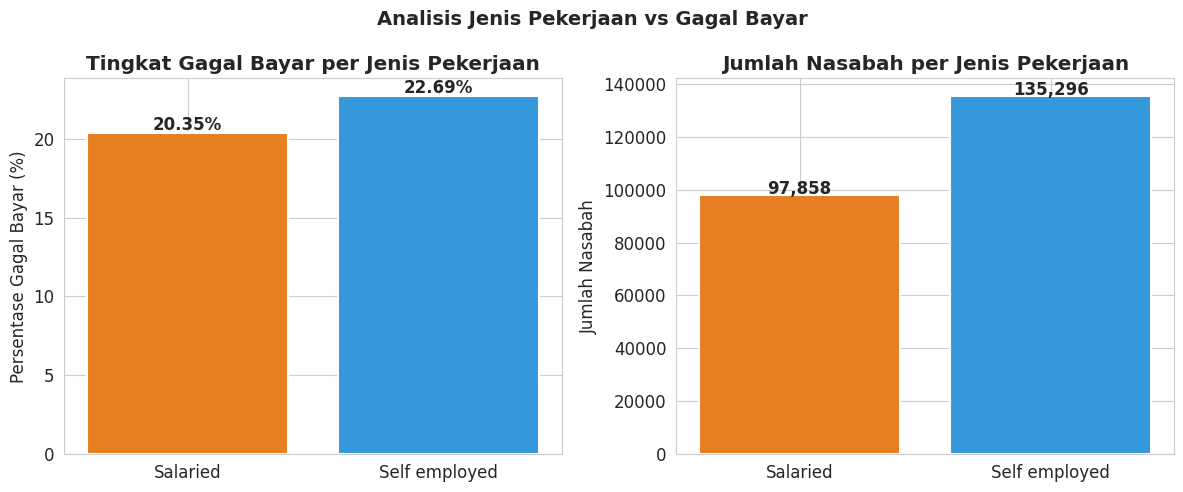

Chart 2 berhasil disimpan!


In [ ]:
# Analisis Employment Type vs Gagal Bayar
emp_default = df.groupby('Employment.Type')['loan_default'].agg(['sum', 'count'])
emp_default['persen_default'] = (emp_default['sum'] / emp_default['count'] * 100).round(2)
emp_default.columns = ['Gagal Bayar', 'Total', 'Persen Default (%)']

print("=== EMPLOYMENT TYPE VS GAGAL BAYAR ===")
print(emp_default)

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Chart kiri: jumlah absolut
axes[0].bar(emp_default.index,
            emp_default['Persen Default (%)'],
            color=['#e67e22', '#3498db'],
            edgecolor='white', linewidth=1.5)
axes[0].set_title('Tingkat Gagal Bayar per Jenis Pekerjaan', fontweight='bold')
axes[0].set_ylabel('Persentase Gagal Bayar (%)')
for i, v in enumerate(emp_default['Persen Default (%)']):
    axes[0].text(i, v + 0.2, f'{v}%', ha='center', fontweight='bold')

# Chart kanan: jumlah nasabah
axes[1].bar(emp_default.index,
            emp_default['Total'],
            color=['#e67e22', '#3498db'],
            edgecolor='white', linewidth=1.5)
axes[1].set_title('Jumlah Nasabah per Jenis Pekerjaan', fontweight='bold')
axes[1].set_ylabel('Jumlah Nasabah')
for i, v in enumerate(emp_default['Total']):
    axes[1].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

plt.suptitle('Analisis Jenis Pekerjaan vs Gagal Bayar', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Dunia Data ku/Project/Project PT dipo star finance/chart2_employment_default.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 berhasil disimpan!")

**Temuan Insight bisnis ke-2 :**

Nasabah wiraswasta (Self employed) punya tingkat gagal bayar 22.69% vs karyawan tetap 20.35% — selisihnya sekitar 2.3%. Tidak dramatis, tapi konsisten. Artinya jenis pekerjaan saja bukan faktor penentu utama gagal bayar — perlu dikombinasikan dengan faktor lain seperti skor kredit dan LTV.

## Pertanyaan 3: Apakah LTV tinggi berbanding lurus dengan risiko gagal bayar?

=== LTV KATEGORI VS GAGAL BAYAR ===
                         Gagal Bayar  Total Nasabah  Persen Default (%)
LTV_Kategori                                                           
1. Rendah (<60%)                3611          25993               13.89
2. Sedang (60-75%)             15555          79479               19.57
3. Tinggi (75-90%)             31169         126463               24.65
4. Sangat Tinggi (>90%)          276           1219               22.64


/tmp/ipykernel_1425/2610520317.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(ltv_default.index, rotation=15, ha='right')
/tmp/ipykernel_1425/2610520317.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(ltv_default.index, rotation=15, ha='right')


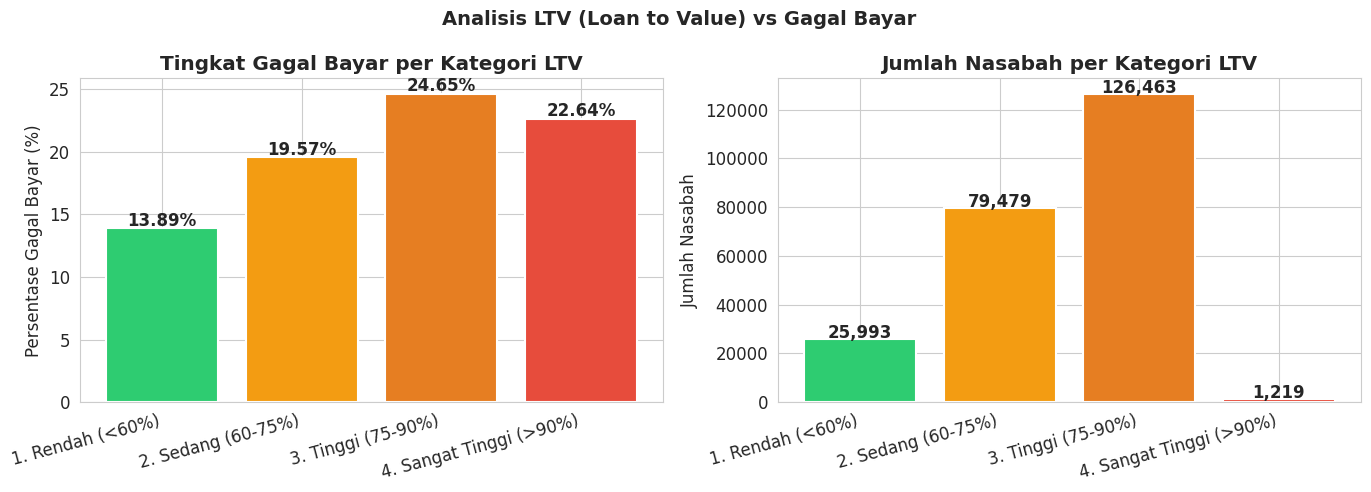

Chart 3 berhasil disimpan!


In [ ]:
# Buat kategori LTV
def kategori_ltv(ltv):
    if ltv < 60:
        return '1. Rendah (<60%)'
    elif ltv < 75:
        return '2. Sedang (60-75%)'
    elif ltv < 90:
        return '3. Tinggi (75-90%)'
    else:
        return '4. Sangat Tinggi (>90%)'

df['LTV_Kategori'] = df['ltv'].apply(kategori_ltv)

# Analisis LTV vs default
ltv_default = df.groupby('LTV_Kategori')['loan_default'].agg(['sum', 'count'])
ltv_default['persen_default'] = (ltv_default['sum'] / ltv_default['count'] * 100).round(2)
ltv_default.columns = ['Gagal Bayar', 'Total Nasabah', 'Persen Default (%)']

print("=== LTV KATEGORI VS GAGAL BAYAR ===")
print(ltv_default)

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

warna = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']

# Chart kiri: persentase default per kategori LTV
axes[0].bar(ltv_default.index,
            ltv_default['Persen Default (%)'],
            color=warna, edgecolor='white', linewidth=1.5)
axes[0].set_title('Tingkat Gagal Bayar per Kategori LTV', fontweight='bold')
axes[0].set_ylabel('Persentase Gagal Bayar (%)')
axes[0].set_xticklabels(ltv_default.index, rotation=15, ha='right')
for i, v in enumerate(ltv_default['Persen Default (%)']):
    axes[0].text(i, v + 0.2, f'{v}%', ha='center', fontweight='bold')

# Chart kanan: jumlah nasabah per kategori
axes[1].bar(ltv_default.index,
            ltv_default['Total Nasabah'],
            color=warna, edgecolor='white', linewidth=1.5)
axes[1].set_title('Jumlah Nasabah per Kategori LTV', fontweight='bold')
axes[1].set_ylabel('Jumlah Nasabah')
axes[1].set_xticklabels(ltv_default.index, rotation=15, ha='right')
for i, v in enumerate(ltv_default['Total Nasabah']):
    axes[1].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

plt.suptitle('Analisis LTV (Loan to Value) vs Gagal Bayar', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Dunia Data ku/Project/Project PT dipo star finance/chart3_ltv_default.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 berhasil disimpan!")

**Temuan insight bisnis ke-3 :**

Tren LTV vs gagal bayar sangat jelas — makin tinggi LTV, makin tinggi risiko gagal bayar:

* LTV rendah < 60% → hanya 13.89% gagal bayar
* LTV sedang 60-75% → 19.57%
* LTV tinggi 75-90% → 24.65% ← mayoritas nasabah ada di sini (126 ribu!)
* LTV sangat tinggi > 90% → 22.64%

**Rekomendasi bisnis** : Perusahaan sebaiknya memperketat syarat uang muka minimum untuk nasabah dengan LTV di atas 75%, karena segmen ini menyumbang risiko terbesar secara volume.

## Pertanyaan 4: Usia berapa nasabah paling sering gagal bayar?

=== USIA vs GAGAL BAYAR ===
                Gagal Bayar  Total Nasabah  Persen Default (%)
Usia_Kategori                                                 
1. <25 tahun          10820          44887               24.10
2. 25-34 tahun        19920          89896               22.16
3. 35-44 tahun        12121          59291               20.44
4. 45+ tahun           7750          39080               19.83


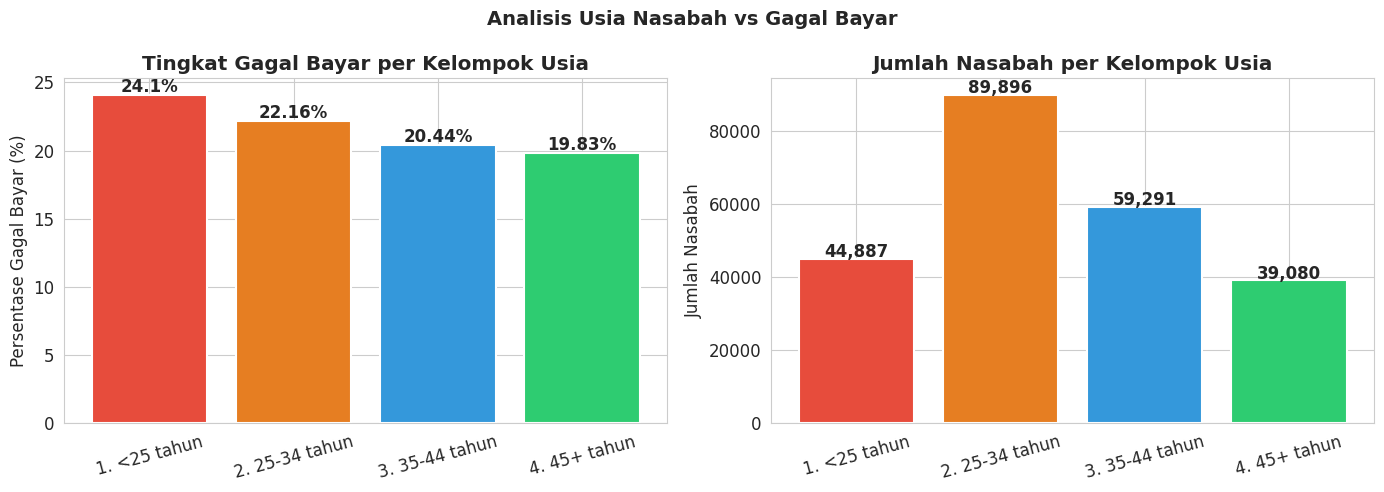

Chart 4 berhasil disimpan!


In [ ]:
# Buat kategori usia
def kategori_usia(usia):
    if usia < 25:
        return '1. <25 tahun'
    elif usia < 35:
        return '2. 25-34 tahun'
    elif usia < 45:
        return '3. 35-44 tahun'
    else:
        return '4. 45+ tahun'

df['Usia_Kategori'] = df['Usia'].apply(kategori_usia)

# Analisis usia vs default
usia_default = df.groupby('Usia_Kategori')['loan_default'].agg(['sum', 'count'])
usia_default['persen_default'] = (usia_default['sum'] / usia_default['count'] * 100).round(2)
usia_default.columns = ['Gagal Bayar', 'Total Nasabah', 'Persen Default (%)']

print("=== USIA vs GAGAL BAYAR ===")
print(usia_default)

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

warna = ['#e74c3c', '#e67e22', '#3498db', '#2ecc71']

axes[0].bar(usia_default.index,
            usia_default['Persen Default (%)'],
            color=warna, edgecolor='white', linewidth=1.5)
axes[0].set_title('Tingkat Gagal Bayar per Kelompok Usia', fontweight='bold')
axes[0].set_ylabel('Persentase Gagal Bayar (%)')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(usia_default['Persen Default (%)']):
    axes[0].text(i, v + 0.2, f'{v}%', ha='center', fontweight='bold')

axes[1].bar(usia_default.index,
            usia_default['Total Nasabah'],
            color=warna, edgecolor='white', linewidth=1.5)
axes[1].set_title('Jumlah Nasabah per Kelompok Usia', fontweight='bold')
axes[1].set_ylabel('Jumlah Nasabah')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(usia_default['Total Nasabah']):
    axes[1].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

plt.suptitle('Analisis Usia Nasabah vs Gagal Bayar', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Dunia Data ku/Project/Project PT dipo star finance/chart4_usia_default.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 berhasil disimpan!")

**Temuan insight bisnis ke-4**:

Makin muda nasabah, makin tinggi risiko gagal bayarnya — trennya konsisten turun:

* Usia < 25 tahun → 24.1% gagal bayar (tertinggi)
* Usia 25-34 tahun → 22.16%
* Usia 35-44 tahun → 20.44%
* Usia 45+ tahun → 19.83% (terendah)

**Rekomendasi bisnis**: Nasabah muda di bawah 25 tahun perlu pengawasan lebih ketat atau persyaratan tambahan seperti guarantor, karena risiko gagalnya hampir 25% — 1 dari 4 orang.

## Pertanyaan 5 — Skor Kredit vs Gagal Bayar

=== KATEGORI SKOR KREDIT ===
                                                    Gagal Bayar   Total  \
PERFORM_CNS.SCORE.DESCRIPTION                                             
Not Scored: More than 50 active Accounts found                0       3   
B-Very Low Risk                                            1208    9201   
D-Very Low Risk                                            1699   11358   
A-Very Low Risk                                            2341   14124   
E-Low Risk                                                 1000    5821   
C-Very Low Risk                                            2770   16045   
Not Scored: No Activity seen on the customer (I...          530    2885   
F-Low Risk                                                 1580    8485   
Not Scored: No Updates available in last 36 months          292    1534   
G-Low Risk                                                  786    3988   
Not Scored: Not Enough Info available on the cu...          770    3672

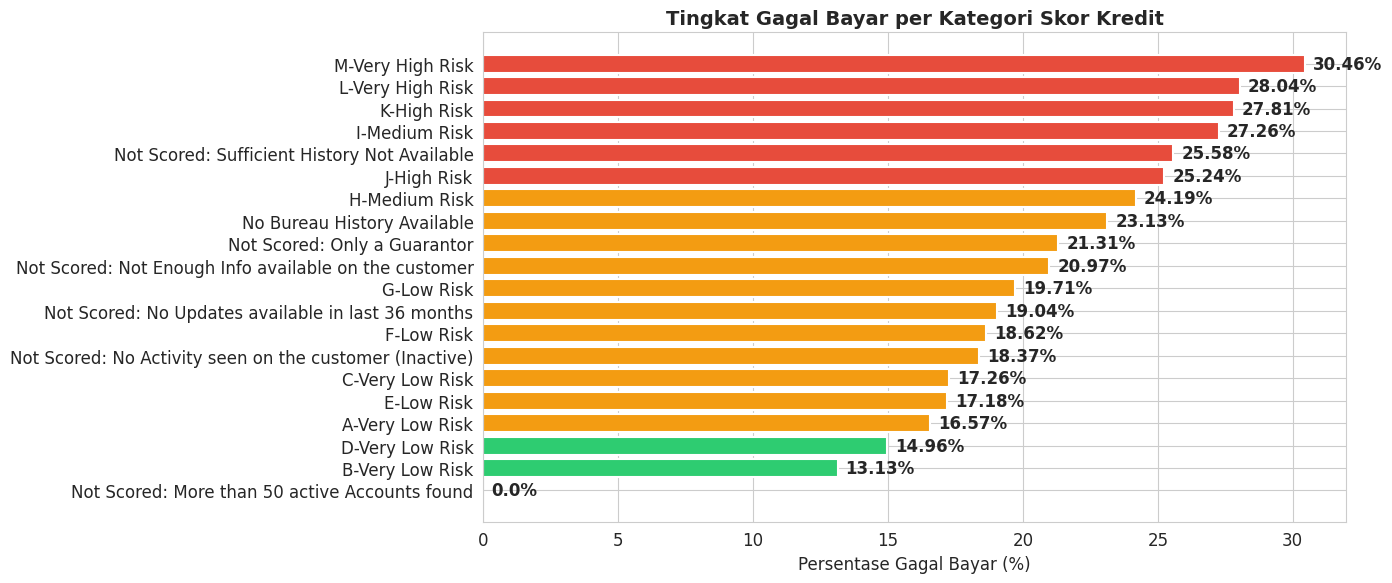

Chart 5 berhasil disimpan!


In [ ]:
# Lihat dulu kategori skor kredit yang ada
print("=== KATEGORI SKOR KREDIT ===")
skor_desc = df.groupby('PERFORM_CNS.SCORE.DESCRIPTION')['loan_default'].agg(['sum','count'])
skor_desc['persen_default'] = (skor_desc['sum'] / skor_desc['count'] * 100).round(2)
skor_desc.columns = ['Gagal Bayar', 'Total', 'Persen Default (%)']
skor_desc = skor_desc.sort_values('Persen Default (%)', ascending=True)
print(skor_desc)

# Visualisasi
fig, ax = plt.subplots(figsize=(14, 6))

warna_bar = ['#2ecc71' if p < 15 else '#f39c12' if p < 25 else '#e74c3c'
             for p in skor_desc['Persen Default (%)']]

bars = ax.barh(skor_desc.index,
               skor_desc['Persen Default (%)'],
               color=warna_bar, edgecolor='white', linewidth=1.5)

ax.set_title('Tingkat Gagal Bayar per Kategori Skor Kredit', fontweight='bold', fontsize=14)
ax.set_xlabel('Persentase Gagal Bayar (%)')

for bar, v in zip(bars, skor_desc['Persen Default (%)']):
    ax.text(v + 0.3, bar.get_y() + bar.get_height()/2,
            f'{v}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Dunia Data ku/Project/Project PT dipo star finance/chart5_skorkreditdefault.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 berhasil disimpan!")

**Temuan insight bisnis ke-5 :**

Skor kredit terbukti sangat prediktif:

* Nasabah Very Low Risk (B) → hanya 13.13% gagal bayar
* Nasabah Very High Risk (M) → 30.46% gagal bayar — hampir 3x lipat!
* Tren naik sangat konsisten dari B sampai M

Tapi ada temuan mengejutkan — **"No Bureau History Available" ada 116.950** nasabah (separuh dari seluruh data!) dengan gagal bayar 23.13%. Ini nasabah yang tidak punya riwayat kredit sama sekali.

**Rekomendasi bisnis:** Nasabah tanpa riwayat kredit harus diperlakukan seperti nasabah medium-high risk, bukan diabaikan begitu saja.

# **Dashboard**

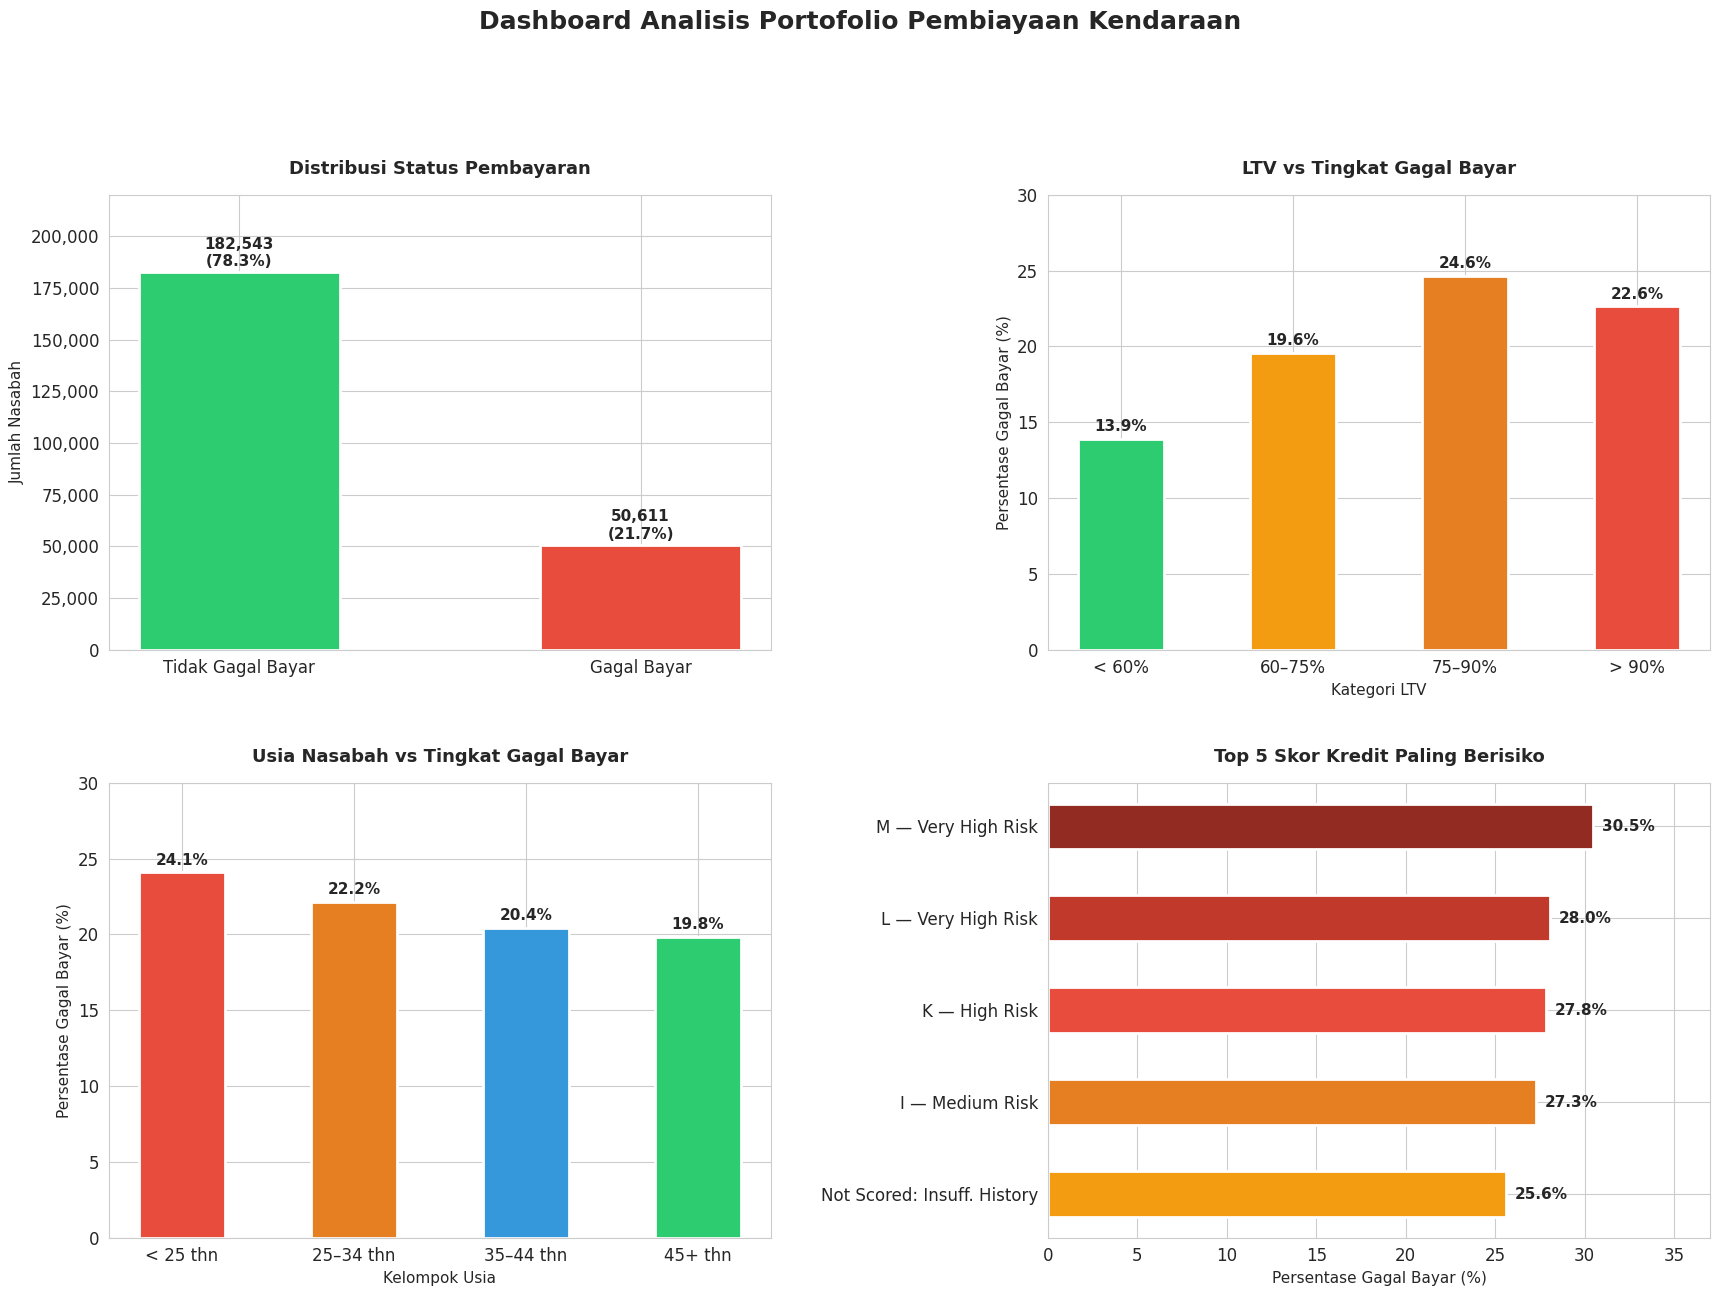

Dashboard final berhasil disimpan!


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle('Dashboard Analisis Portofolio Pembiayaan Kendaraan',
             fontsize=18, fontweight='bold', y=1.02)

# Chart 1: Distribusi default
jumlah = df['loan_default'].value_counts()
bars1 = axes[0,0].bar(['Tidak Gagal Bayar', 'Gagal Bayar'],
                       jumlah.values, color=['#2ecc71', '#e74c3c'],
                       edgecolor='white', linewidth=2, width=0.5)
axes[0,0].set_title('Distribusi Status Pembayaran', fontweight='bold', fontsize=13, pad=15)
axes[0,0].set_ylabel('Jumlah Nasabah', fontsize=11)
axes[0,0].set_ylim(0, 220000)
axes[0,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for bar, v in zip(bars1, jumlah.values):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, v + 3000,
                   f'{v:,}\n({v/len(df)*100:.1f}%)',
                   ha='center', fontsize=11, fontweight='bold')

# Chart 2: LTV vs default
ltv_persen = df.groupby('LTV_Kategori')['loan_default'].mean() * 100
warna_ltv = ['#2ecc71','#f39c12','#e67e22','#e74c3c']
bars2 = axes[0,1].bar(['< 60%', '60–75%', '75–90%', '> 90%'],
                       ltv_persen.values, color=warna_ltv,
                       edgecolor='white', linewidth=2, width=0.5)
axes[0,1].set_title('LTV vs Tingkat Gagal Bayar', fontweight='bold', fontsize=13, pad=15)
axes[0,1].set_ylabel('Persentase Gagal Bayar (%)', fontsize=11)
axes[0,1].set_xlabel('Kategori LTV', fontsize=11)
axes[0,1].set_ylim(0, 30)
for bar, v in zip(bars2, ltv_persen.values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, v + 0.5,
                   f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

# Chart 3: Usia vs default
usia_persen = df.groupby('Usia_Kategori')['loan_default'].mean() * 100
warna_usia = ['#e74c3c','#e67e22','#3498db','#2ecc71']
bars3 = axes[1,0].bar(['< 25 thn', '25–34 thn', '35–44 thn', '45+ thn'],
                       usia_persen.values, color=warna_usia,
                       edgecolor='white', linewidth=2, width=0.5)
axes[1,0].set_title('Usia Nasabah vs Tingkat Gagal Bayar', fontweight='bold', fontsize=13, pad=15)
axes[1,0].set_ylabel('Persentase Gagal Bayar (%)', fontsize=11)
axes[1,0].set_xlabel('Kelompok Usia', fontsize=11)
axes[1,0].set_ylim(0, 30)
for bar, v in zip(bars3, usia_persen.values):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, v + 0.5,
                   f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

# Chart 4: Top 5 skor kredit paling berisiko
top_risiko = df.groupby('PERFORM_CNS.SCORE.DESCRIPTION')['loan_default'].mean() * 100
top_risiko = top_risiko.sort_values(ascending=True).tail(5)

label_bersih = {
    'M-Very High Risk': 'M — Very High Risk',
    'L-Very High Risk': 'L — Very High Risk',
    'K-High Risk': 'K — High Risk',
    'I-Medium Risk': 'I — Medium Risk',
    'Not Scored: Sufficient History Not Available': 'Not Scored: Insuff. History'
}
labels = [label_bersih.get(x, x[:25]) for x in top_risiko.index]

bars4 = axes[1,1].barh(labels, top_risiko.values,
                        color=['#f39c12','#e67e22','#e74c3c','#c0392b','#922b21'],
                        edgecolor='white', linewidth=2, height=0.5)
axes[1,1].set_title('Top 5 Skor Kredit Paling Berisiko', fontweight='bold', fontsize=13, pad=15)
axes[1,1].set_xlabel('Persentase Gagal Bayar (%)', fontsize=11)
axes[1,1].set_xlim(0, 37)
for bar, v in zip(bars4, top_risiko.values):
    axes[1,1].text(v + 0.5, bar.get_y() + bar.get_height()/2,
                   f'{v:.1f}%', va='center', fontsize=11, fontweight='bold')

plt.tight_layout(pad=3.0)
plt.savefig('/content/drive/MyDrive/Dunia Data ku/Project/Project PT dipo star finance/dashboard_final.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard final berhasil disimpan!")